<a href="https://colab.research.google.com/github/Nolan-Jgr/golf-analytics-project/blob/main/notebooks/02_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf Analytics Project
## Phase 2: Exploratory Data Analysis

### Objective
The purpose of this phase is to explore the cleaned golf dataset and identify
patterns and relationships between player performance, scoring, tournament
performance, and earnings.

The analysis will use descriptive statistics and data visualization to
develop insights that will guide the SQL analysis and dashboard development
in later phases.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Fictional_Golf_Project/Data/Fictional_Golf_Dataset_25000_Rows_Cleaned.csv")
df.head()

,PlayerID,FirstName,LastName,Age,Tournament,Season,Round,Course,CoursePar,DriveDistance,FairwaysHit,GIR,Putts,Birdies,Bogeys,Score,StrokesGainedTotal,Earnings,ScoreToPar,BirdiePct,BogeyPct,EarningsPerStroke
0,328,Jordan,Smith,22,Spring Classic,2025,3,Cedar Hills,70,311.1,4,7,27,3,4,69,1.02,16894.88,-1,0.166667,0.222222,244.853333
1,288,Casey,Hall,36,Lakes Championship,2025,4,Pine Ridge,70,295.6,10,11,28,2,1,76,4.57,6699.68,6,0.111111,0.055556,88.153684
2,173,Jordan,Johnson,45,Lakes Championship,2025,4,Cedar Hills,70,294.5,11,14,25,6,0,73,0.52,14671.47,3,0.333333,0.000000,200.979041
3,425,Cameron,Wilson,19,River Open,2025,2,Lakeview,72,330.2,5,12,28,7,5,66,3.34,10359.10,-6,0.388889,0.277778,156.956061
4,84,Sam,Wilson,40,Spring Classic,2025,2,Cedar Hills,72,280.3,7,8,31,6,2,72,4.90,3656.65,0,0.333333,0.111111,50.786806


In [ ]:
df.shape

(25000, 22)

## **Overview**

In [26]:
df.describe()

,PlayerID,Age,Season,Round,CoursePar,DriveDistance,FairwaysHit,GIR,Putts,Birdies,Bogeys,Score,StrokesGainedTotal,Earnings,ScoreToPar,BirdiePct,BogeyPct,EarningsPerStroke
count,25000.000000,25000.000000,25000.0,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,250.282160,31.471400,2025.0,2.501760,70.999880,294.804636,9.025600,11.991240,30.019760,3.984120,2.991040,70.989640,-0.011954,12423.747346,-0.010240,0.221340,0.166169,175.784473
std,144.614353,8.054997,0.0,1.116444,0.813478,17.989249,3.169275,3.734354,3.755307,2.582939,2.003018,4.969431,2.894078,8306.873082,4.903963,0.143497,0.111279,118.424760
min,1.000000,18.000000,2025.0,1.000000,70.000000,208.800000,4.000000,6.000000,24.000000,0.000000,0.000000,62.000000,-5.000000,0.000000,-8.000000,0.000000,0.000000,0.000000
25%,125.000000,24.000000,2025.0,2.000000,70.000000,282.800000,6.000000,9.000000,27.000000,2.000000,1.000000,67.000000,-2.530000,5983.530000,-4.000000,0.111111,0.055556,84.336375
50%,249.000000,31.000000,2025.0,3.000000,71.000000,294.800000,9.000000,12.000000,30.000000,4.000000,3.000000,71.000000,0.000000,12105.105000,0.000000,0.222222,0.166667,170.119731
75%,376.000000,38.000000,2025.0,3.000000,72.000000,306.800000,12.000000,15.000000,33.000000,6.000000,5.000000,75.000000,2.470000,18165.857500,4.000000,0.333333,0.277778,256.017051
max,500.000000,45.000000,2025.0,4.000000,72.000000,380.300000,14.000000,18.000000,36.000000,8.000000,6.000000,80.000000,5.000000,50146.300000,8.000000,0.444444,0.333333,737.445588


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PlayerID            25000 non-null  int64  
 1   FirstName           25000 non-null  object 
 2   LastName            25000 non-null  object 
 3   Age                 25000 non-null  int64  
 4   Tournament          25000 non-null  object 
 5   Season              25000 non-null  int64  
 6   Round               25000 non-null  int64  
 7   Course              25000 non-null  object 
 8   CoursePar           25000 non-null  int64  
 9   DriveDistance       25000 non-null  float64
 10  FairwaysHit         25000 non-null  int64  
 11  GIR                 25000 non-null  int64  
 12  Putts               25000 non-null  int64  
 13  Birdies             25000 non-null  int64  
 14  Bogeys              25000 non-null  int64  
 15  Score               25000 non-null  int64  
 16  Stro

In [28]:
df.nunique()

,0
PlayerID,500
FirstName,10
LastName,10
Age,28
Tournament,5
Season,1
Round,4
Course,5
CoursePar,3
DriveDistance,1087


## **Overall Performance**

Before examining individual players and tournaments, I will establish baseline performance metrics for the entire dataset.

In [ ]:
print("Average Score:", round(df["Score"].mean(),2))
print("Average Score to Par:", round(df["ScoreToPar"].mean(), 2))
print("Average Driving Distance:", round(df["DriveDistance"].mean(), 2))
print("Average Putts:", round(df["Putts"].mean(), 2))
print("Average GIR:", round(df["GIR"].mean(), 2))
print("Average Birdies:", round(df["Birdies"].mean(), 2))
print("Average Bogeys:", round(df["Bogeys"].mean(), 2))
print("Average Earnings:", round(df["Earnings"].mean(), 2))
print("Average Strokes Gained:", round(df["StrokesGainedTotal"].mean(), 2))

Average Score: 70.99
Average Score to Par: -0.01
Average Driving Distance: 294.8
Average Putts: 30.02
Average GIR: 11.99
Average Birdies: 3.98
Average Bogeys: 2.99
Average Earnings: 12423.75
Average Strokes Gained: -0.01


In [30]:
fairway_percentage = (df["FairwaysHit"].mean()/14) * 100

gir_percentage = (df["GIR"].mean()/18) * 100

print("Average Fairway Percentage:", round(fairway_percentage, 2), "%")
print("Average GIR Percentage:", round(gir_percentage, 2), "%")

Average Fairway Percentage: 64.47 %
Average GIR Percentage: 66.62 %


## **Player Performance**

### Who *are* the best-performing players?

In [11]:
player_summary = (
    df.groupby(["PlayerID","FirstName", "LastName"])
      .agg(
          AverageScore = ("Score", "mean"),
          AverageScoreToPar = ("ScoreToPar", "mean"),
          AverageDrivingDistance = ("DriveDistance", "mean"),
          AveragePutts = ("Putts", "mean"),
          AverageGIR = ("GIR", "mean"),
          AverageBirdies = ("Birdies", "mean"),
          AverageBogeys = ("Bogeys", "mean"),
          TotalEarnings = ("Earnings", "sum")
      )
      .reset_index()
)

player_summary.sort_values(
    "AverageScore"
).head(10)

,PlayerID,FirstName,LastName,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBogeys,TotalEarnings
288,7,Sam,Hall,62.0,-8.0,274.1,31.0,10.0,6.0,0.0,12888.39
11406,289,Cameron,Miller,62.0,-8.0,293.6,35.0,13.0,8.0,5.0,11956.82
11395,288,Sam,Moore,62.0,-8.0,264.4,25.0,7.0,1.0,5.0,7233.85
5910,150,Jamie,Miller,62.0,-8.0,314.3,32.0,9.0,2.0,2.0,12095.20
2931,76,Alex,Moore,62.0,-8.0,288.5,27.0,7.0,4.0,4.0,27557.80
1407,37,Alex,Young,62.0,-8.0,270.5,28.0,14.0,4.0,6.0,10644.11
10863,275,Drew,Young,62.0,-8.0,306.7,28.0,12.0,7.0,3.0,143.29
13096,333,Morgan,Smith,62.0,-8.0,276.0,28.0,13.0,8.0,6.0,23989.34
7711,196,Cameron,Young,62.0,-8.0,262.7,24.0,17.0,0.0,2.0,12347.83
295,7,Taylor,Miller,62.0,-8.0,281.7,32.0,11.0,7.0,2.0,5312.42


### **Score Distribution**

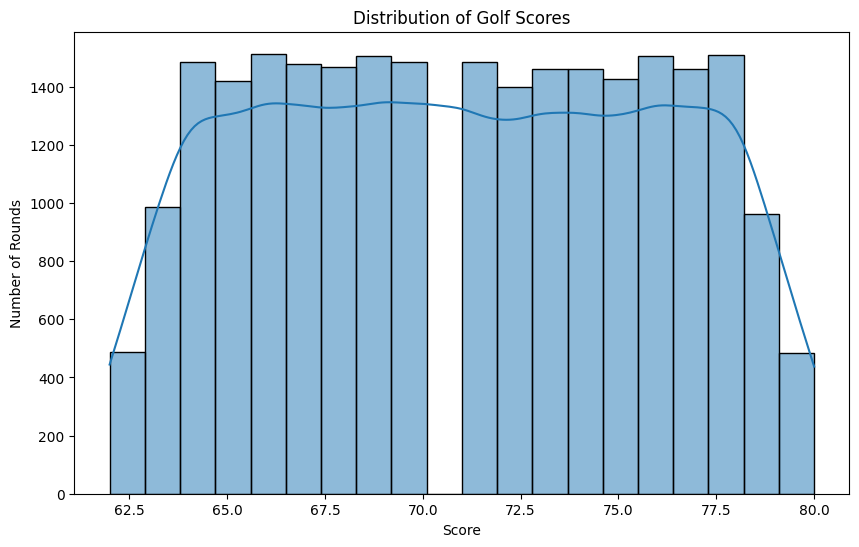

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Golf Scores")
plt.xlabel("Score")
plt.ylabel("Number of Rounds")

plt.show()

### **Score vs Driving Distance**

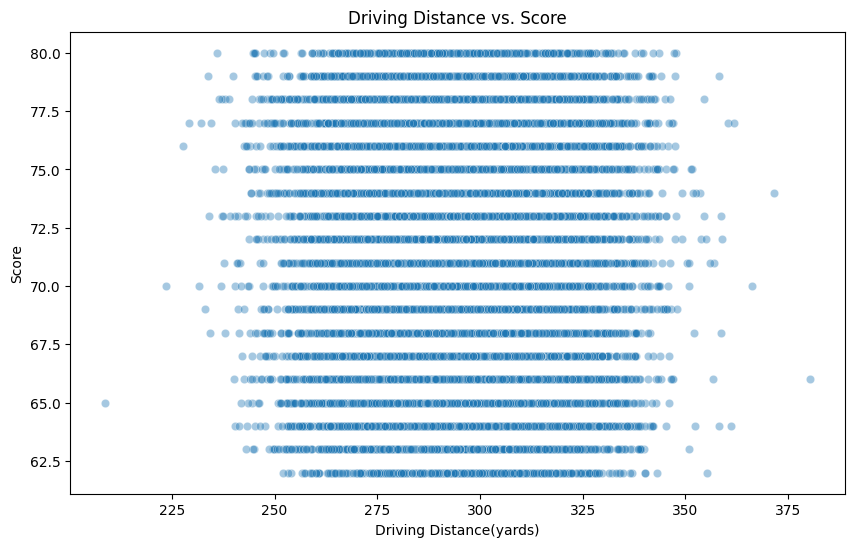

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="DriveDistance",
    y="Score",
    alpha=0.4
)

plt.title("Driving Distance vs. Score")
plt.xlabel("Driving Distance(yards)")
plt.ylabel("Score")
plt.show()

In [10]:
df["DriveDistance"].corr(df["Score"])

np.float64(-0.01462673389289952)

This correlation coefficent is slightly negative but so weak that it can be said there is relatively no correlation between the two.

### **Putting vs Score**

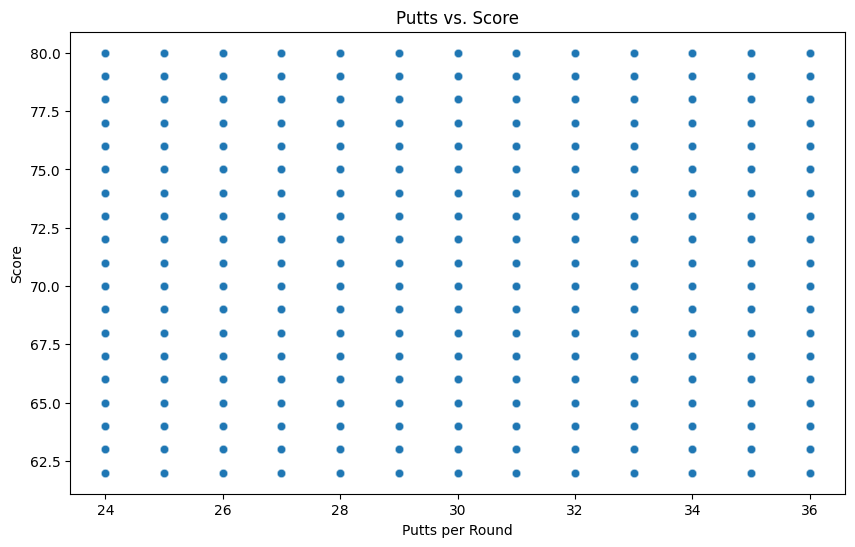

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = df,
    x = "Putts",
    y = "Score",
    alpha = 0.4
)

plt.title("Putts vs. Score")
plt.xlabel("Putts per Round")
plt.ylabel("Score")
plt.show()

In [13]:
df["Putts"].corr(df["Score"])

np.float64(0.00417580744773184)

This correlation coefficent is slightly positive but so weak that it can be said that the two variables are uncorrelated.

### **GIR vs Score**

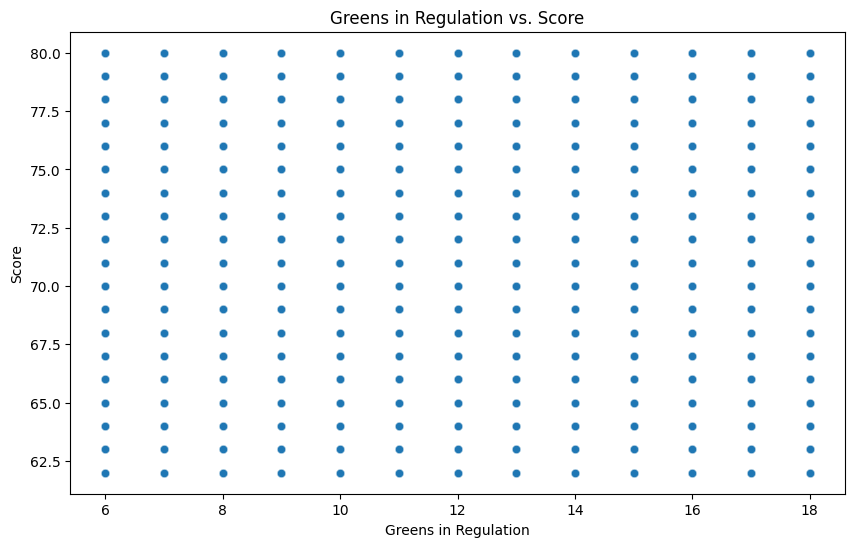

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = df,
    x = "GIR",
    y = "Score",
    alpha = 0.4
)

plt.title("Greens in Regulation vs. Score")
plt.xlabel("Greens in Regulation")
plt.ylabel("Score")
plt.show()

In [15]:
df["GIR"].corr(df["Score"])

np.float64(-0.0035119472216178296)

This correlation coefficent is slightly negative but so week that it can be said that the two variables are uncorrelated.

**Compared to the driving distance correlation coefficent, it can be weakly said that driving distance promotes lower scores than approach play.**

### **Birdies vs Score**

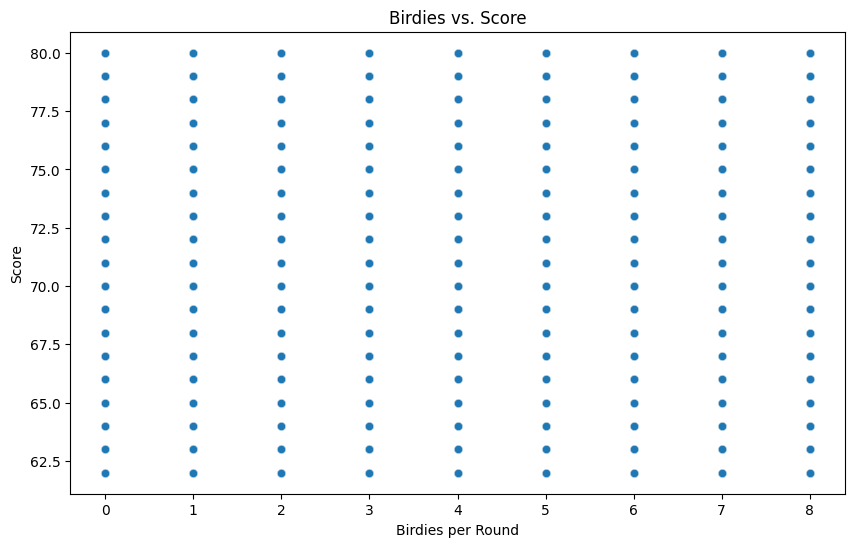

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = df,
    x = "Birdies",
    y = "Score",
    alpha = 0.4
)

plt.title("Birdies vs. Score")
plt.xlabel("Birdies per Round")
plt.ylabel("Score")
plt.show()

In [17]:
df["Birdies"].corr(df["Score"])

np.float64(-0.008374183526600193)

The correlation coefficent is slightly negative but so weak that it can be said these two variables are uncorrelated.

### **Strokes Gained vs Score**

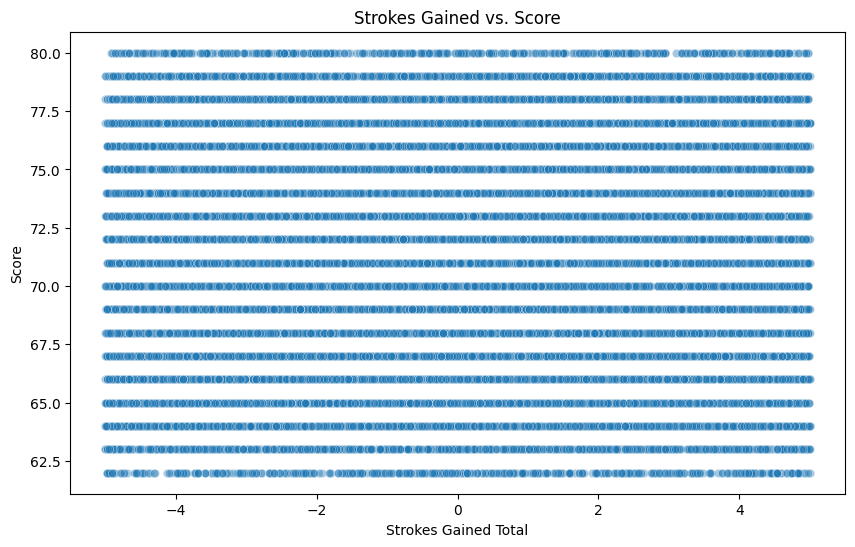

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = df,
    x = "StrokesGainedTotal",
    y = "Score",
    alpha = 0.4
)

plt.title("Strokes Gained vs. Score")
plt.xlabel("Strokes Gained Total")
plt.ylabel("Score")
plt.show()

In [19]:
df["StrokesGainedTotal"].corr(df["Score"])

np.float64(-0.0010456494546241119)

The correlation coefficent is slightly negative but so weak that it can said these two variables are uncorrelated.

## **Tournament Analysis**

In [21]:
tournament_summary = (
    df.groupby("Tournament")
      .agg(
          AverageScore = ("Score", "mean"),
          AverageScoreToPar = ("ScoreToPar", "mean"),
          AveragePutts = ("Putts", "mean"),
          AverageGIR = ("GIR", "mean"),
          AverageBirdies = ("Birdies", "mean")
      )
      .reset_index()
)

tournament_summary.sort_values(
    "AverageScore",
    ascending=False
)

,Tournament,AverageScore,AverageScoreToPar,AveragePutts,AverageGIR,AverageBirdies
2,Mountain Invitational,71.066721,0.077502,30.054719,11.997152,4.006103
3,River Open,71.055292,0.048381,30.024882,11.953199,3.978081
1,Lakes Championship,70.961523,-0.038278,29.997209,11.984848,4.043461
4,Spring Classic,70.951658,-0.050939,30.012785,12.051938,3.973632
0,Coastal Cup,70.913565,-0.087035,30.009804,11.969588,3.919568


Based on the table above, the Mountain Invitational is only slightly the hardest tournament to win.

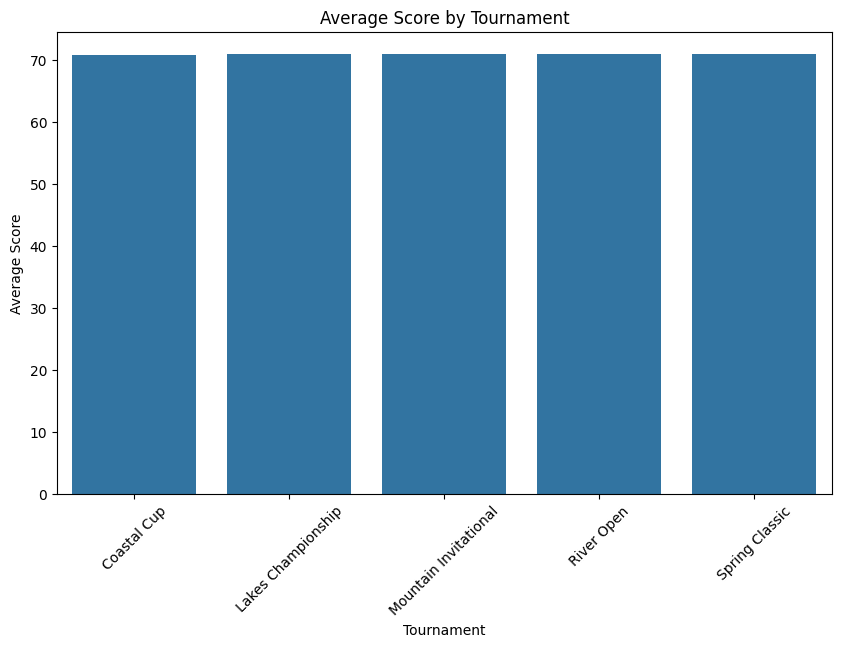

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = tournament_summary,
    x = "Tournament",
    y = "AverageScore"
)

plt.title("Average Score by Tournament")
plt.xlabel("Tournament")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

## **Earnings Analysis**

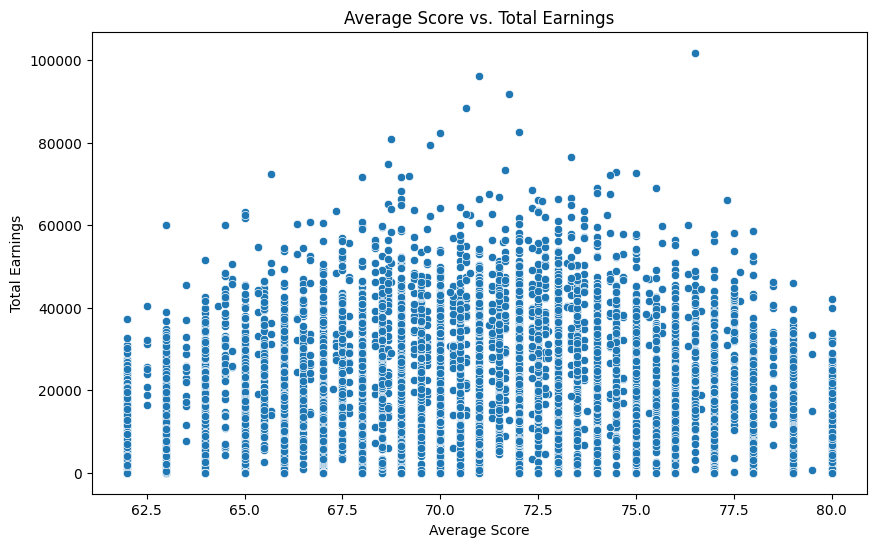

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = player_summary,
    x = "AverageScore",
    y = "TotalEarnings"
)

plt.title("Average Score vs. Total Earnings")
plt.xlabel("Average Score")
plt.ylabel("Total Earnings")
plt.show()

In [24]:
player_summary["AverageScore"].corr(
    player_summary["TotalEarnings"]
)

np.float64(0.008695974418590423)

The correlation coefficent is slightly positive but so weak that is can be said these two variables are uncorrelated.

## **Correlation Matrix**

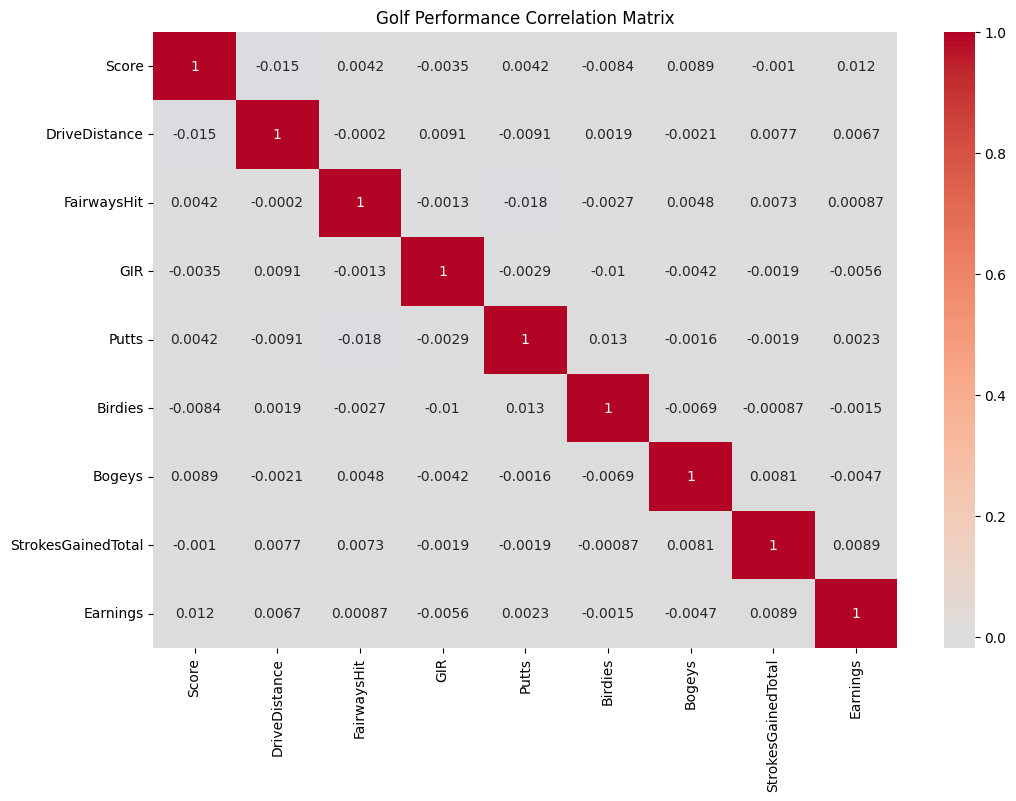

In [25]:
correlation_columns = [
    "Score",
    "DriveDistance",
    "FairwaysHit",
    "GIR",
    "Putts",
    "Birdies",
    "Bogeys",
    "StrokesGainedTotal",
    "Earnings"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center = 0
)

plt.title("Golf Performance Correlation Matrix")
plt.show()

## **Early Insights**

### Finding 1 - Scoring

### Finding 2 - Driving

### Finding 3 - Putting

### Finding 4 - Approach Play

### Finding 5 - Earnings

### Finding 6 - Tournament Difficulty